# Results

## SC Trials 03/02-12/02 (`data/sanity_checks`)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/complete_physics4/model_1.008e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.687880039215088, -2....",0.023147,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.405747413635254, 1.69102...",0.002726,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.658685445785522, -1.9...",0.004142,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.621750831604003, -1....",0.039594,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.426576972007751, 1.1514...",0.002743,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480870962142944, 2.8691...",0.012223,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6037119626998901, -1....",0.003548,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.710173368453979, 2.2700...",0.021869,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.542604684829712, -2....",0.054782,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.495648145675659, -1.6...",0.002041,0.0


In [2]:
# physics only 
import jax.numpy as jnp
from networks import DampedPendulumParamPDE
from forecasters import Forecaster
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")


In [3]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


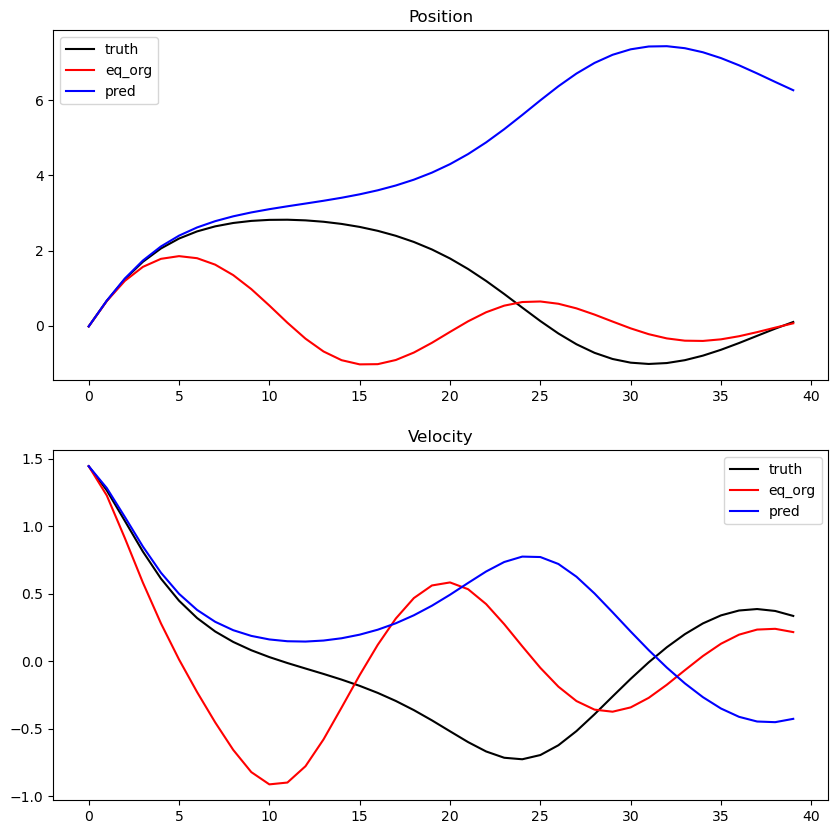

In [4]:
plot_trajectory(12)

[0.52782559 1.32926977]
(1, 2, 40)


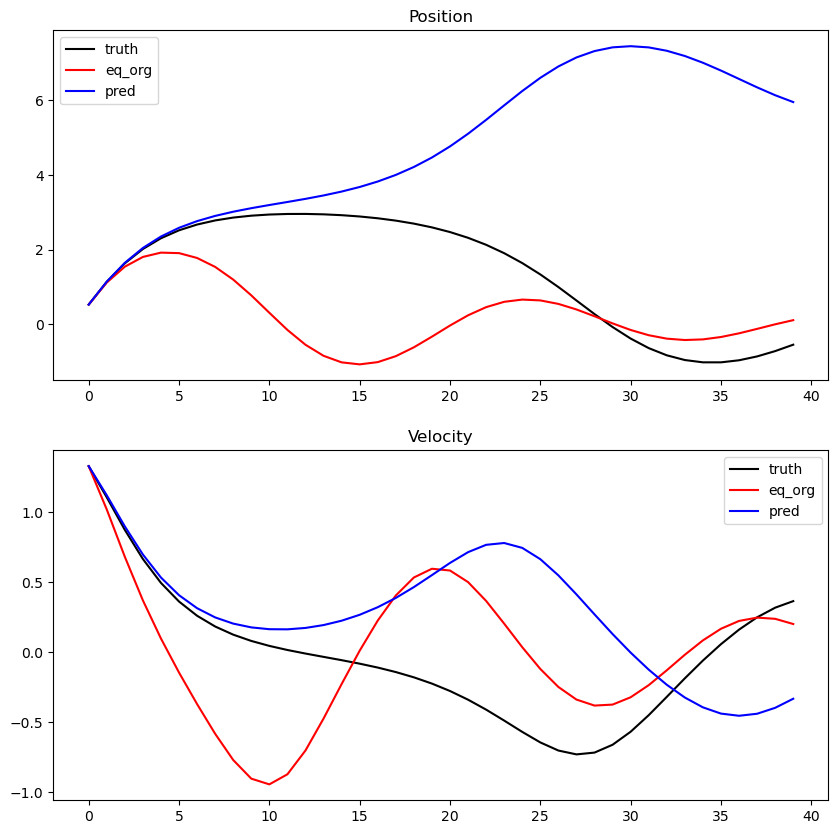

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 40)


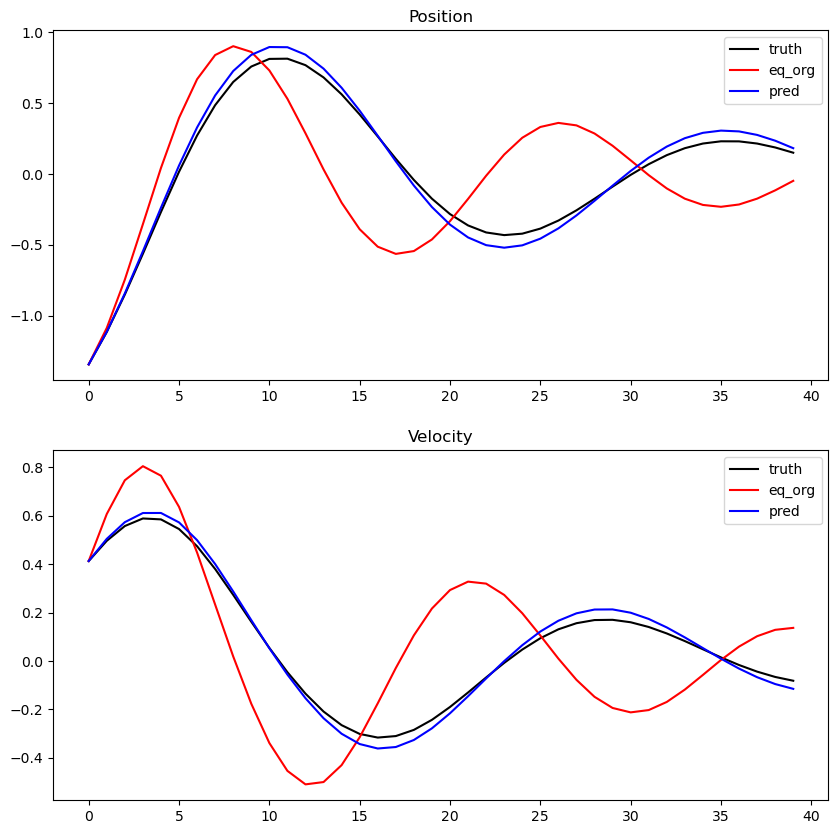

In [6]:
plot_trajectory(24)

In [10]:
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/incomplete_aug3/model_1.508e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.626970410346984, -2....",0.211602,0.002573
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.424392223358154, 1.74875...",0.378943,0.001084
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.628757238388061, -1.9...",0.237589,0.001309
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.6408729553222651, -1...",0.143368,0.002837
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.430660128593444, 1.1600...",0.170913,0.000969
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480446577072143, 2.8727...",0.112306,0.000886
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.574680805206298, -1.8...",0.24868,0.001296
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.737329006195068, 2.3514...",0.099819,0.000981
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.492254257202148, -2....",0.204859,0.002653
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.48915433883667, -1.61...",0.217697,0.001045


In [11]:
model_phy = DampedPendulumParamPDE(is_complete=False, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [12]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


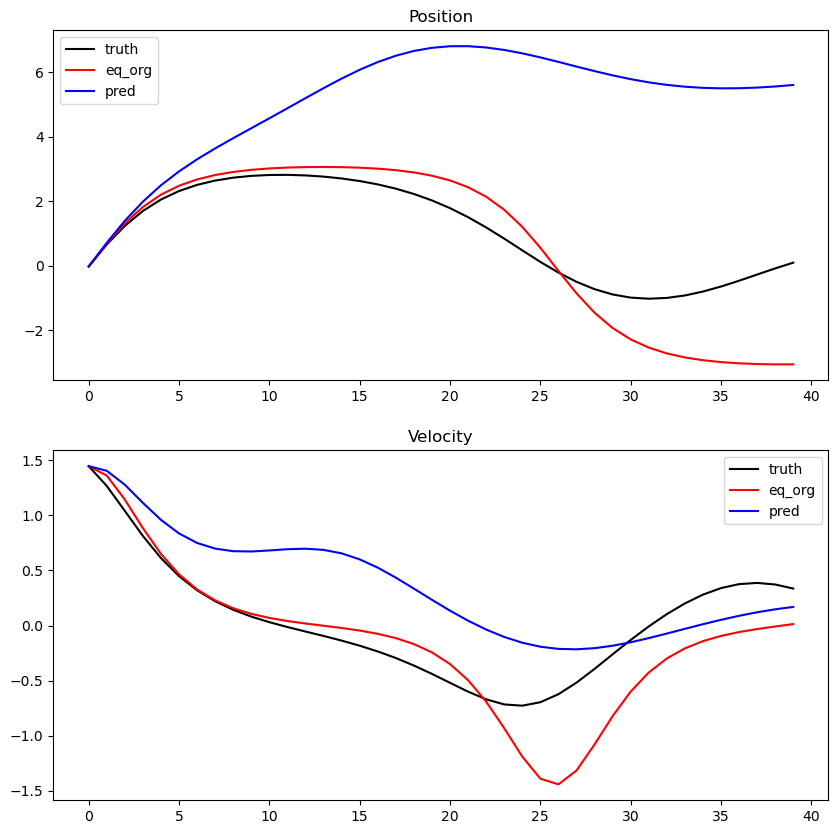

In [13]:
plot_trajectory(12)

[0.52782559 1.32926977]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


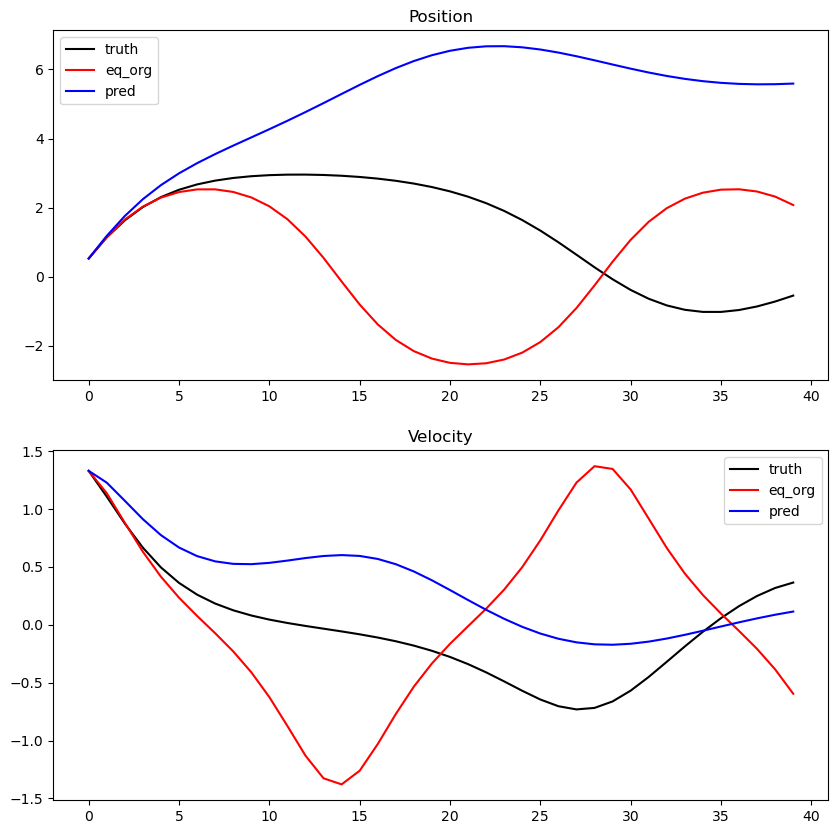

In [14]:
plot_trajectory(22)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


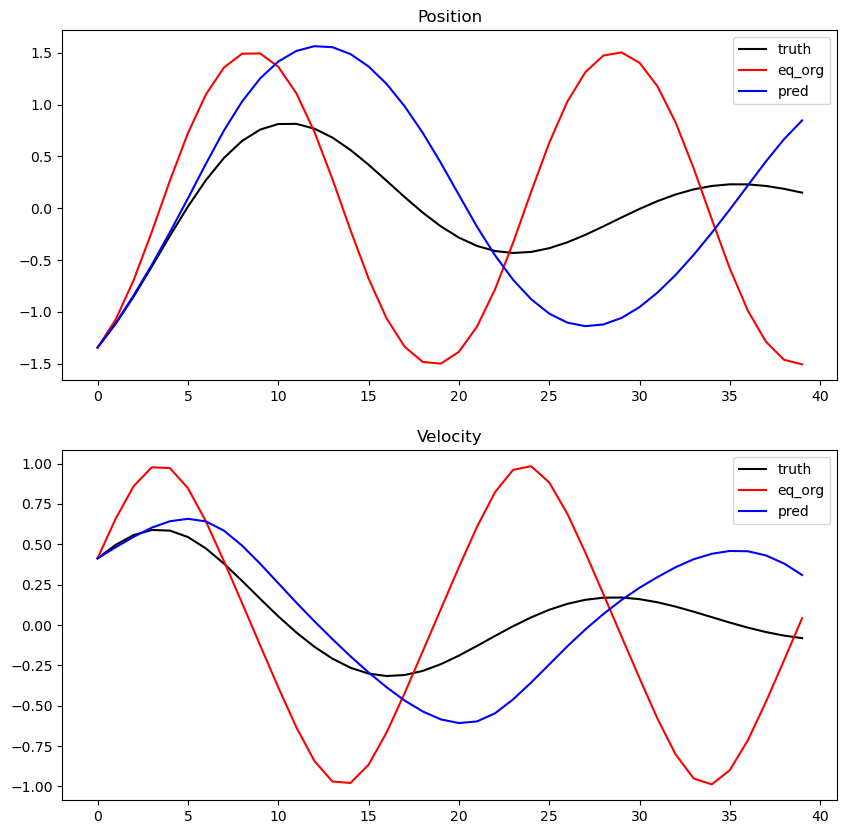

In [15]:
plot_trajectory(24)

### None aug5


In [16]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug5/model_1.006e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6181092262268062, -2...",0.18581,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.340431213378906, 1.58105...",0.101088,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.637307405471801, -1.9...",0.098446,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.559412360191345, -1....",0.156073,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.369356155395507, 1.0821...",0.047644,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.45348310470581, 2.84081...",0.09176,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.582802057266235, -1.8...",0.092699,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.651341915130615, 2.2217...",0.062379,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.469146966934204, -2....",0.25517,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.483283877372741, -1.5...",0.04442,0.0


In [17]:
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [18]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


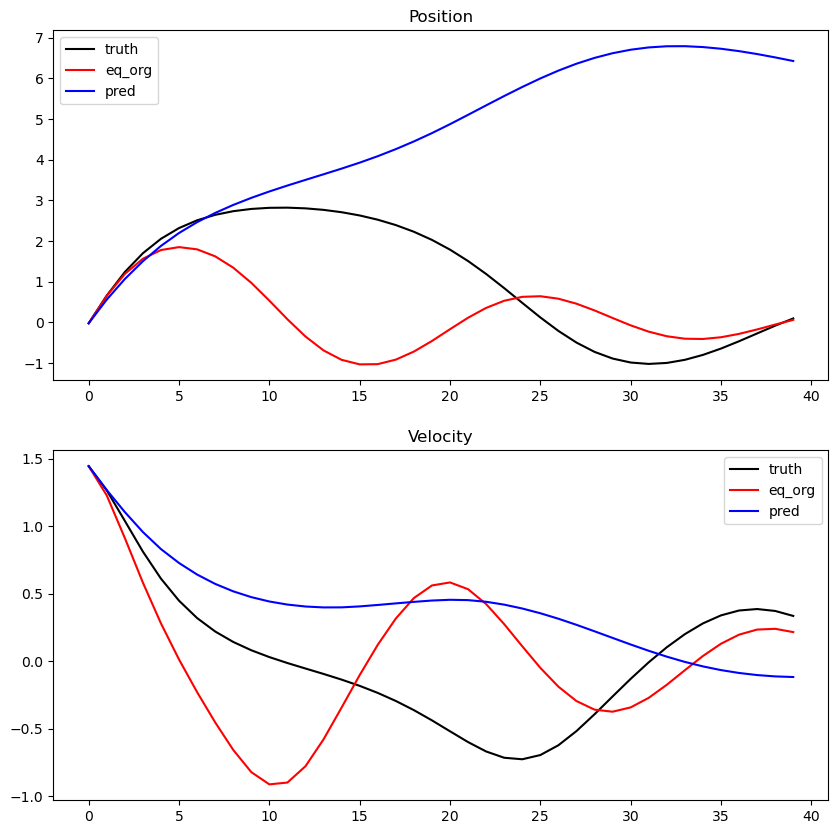

In [19]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


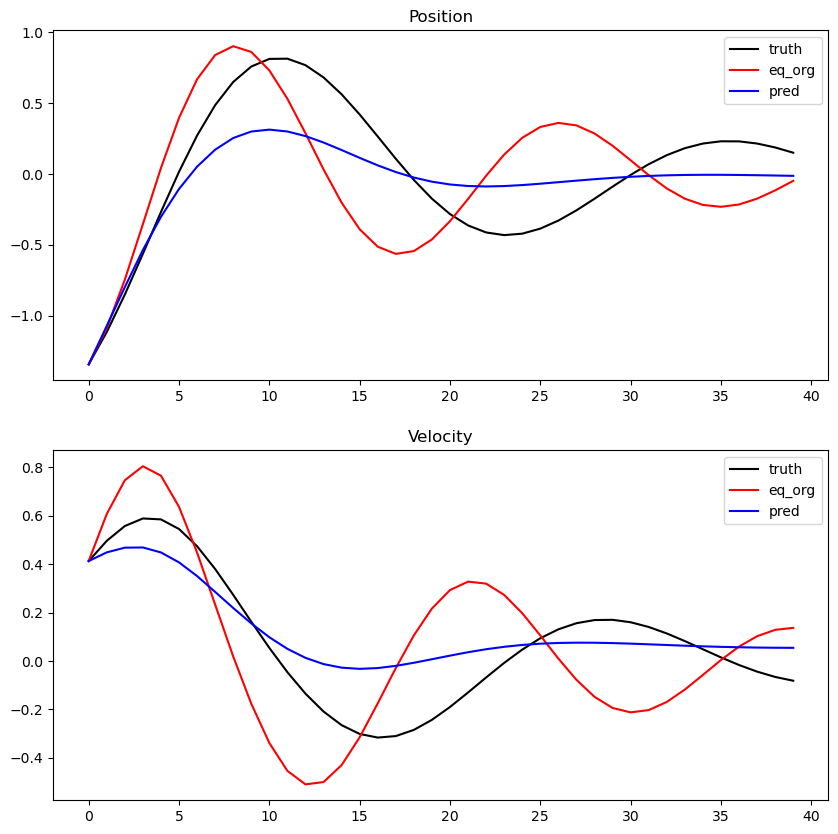

In [20]:
plot_trajectory(24)

### none aug6 

In [22]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug6/model_1.784e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.545371651649475, -2....",0.423295,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.3244702816009521, 1.6016...",1.66484,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.612063407897949, -1.9...",1.102503,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.47063967585563604, -...",0.314862,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.383215904235839, 1.1161...",0.088045,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.423594713211059, 2.8058...",0.327988,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.557781219482421, -1.8...",1.027345,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.577638626098632, 2.1117...",0.171073,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.380985379219055, -2....",0.483737,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.486307859420776, -1.6...",0.317323,0.0


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


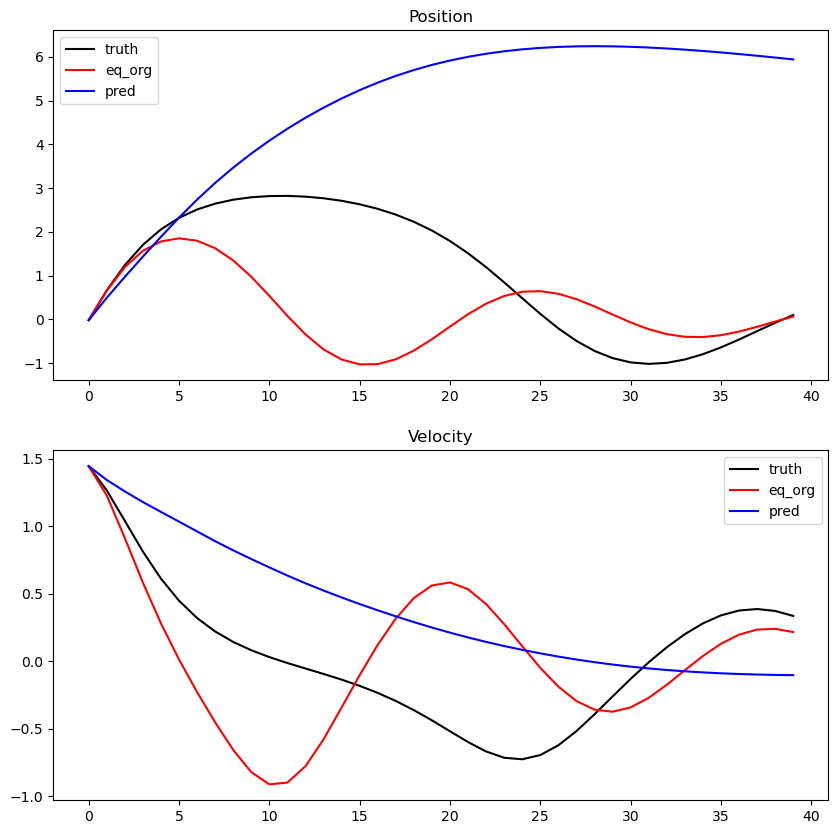

In [24]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


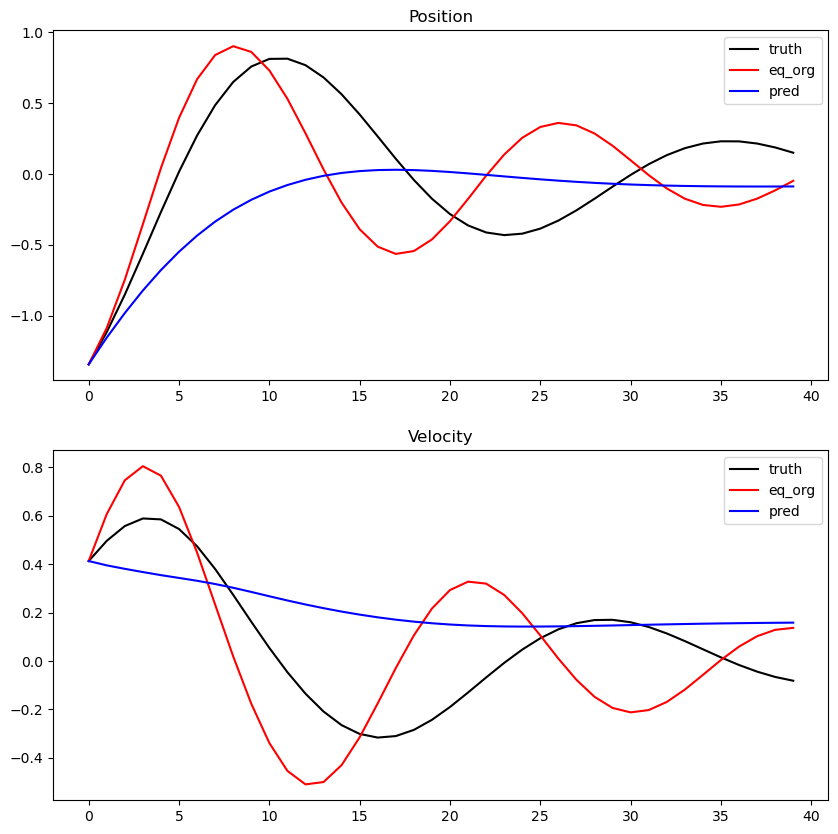

In [25]:
plot_trajectory(24)

## SC Trials debug (`data/tests`)

### None 11

In [20]:
import pandas as pd
results_pth = "/Users/mayajanvier/jax-phynity/data/tests/none_aug_9_se3z528o/model_1.422e-02..json"
results = pd.read_json(results_pth).T
results

ValueError: Trailing data

In [2]:
from networks import PendulumParamPDE
from forecasters import *
model_phy = PendulumParamPDE(is_damped=True, params={"omega0_square": (2*jnp.pi/12)**2, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete",dt=0.5, num_steps=40, integration_method="RK4")

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np


In [4]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = jax.vmap(net_phy)(np.array([results["states"][index]])[:,:,0])
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

In [9]:
phy_out = jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(results["states"][1][1]) - np.array(phy_out[0,1,:])).mean()

1.9989363480438227e-09

In [10]:
phy_out2 =jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(phy_out[0,1,:]) - np.array(phy_out2[0,1,:])).mean()

0.0

In [14]:
phy_out2 = np.array(phy_out2)
phy_out_jnp = jnp.array(phy_out2)
(phy_out_jnp-phy_out).mean()

Array(0., dtype=float32)

[0.52782559 1.32926977]
(1, 2, 41)


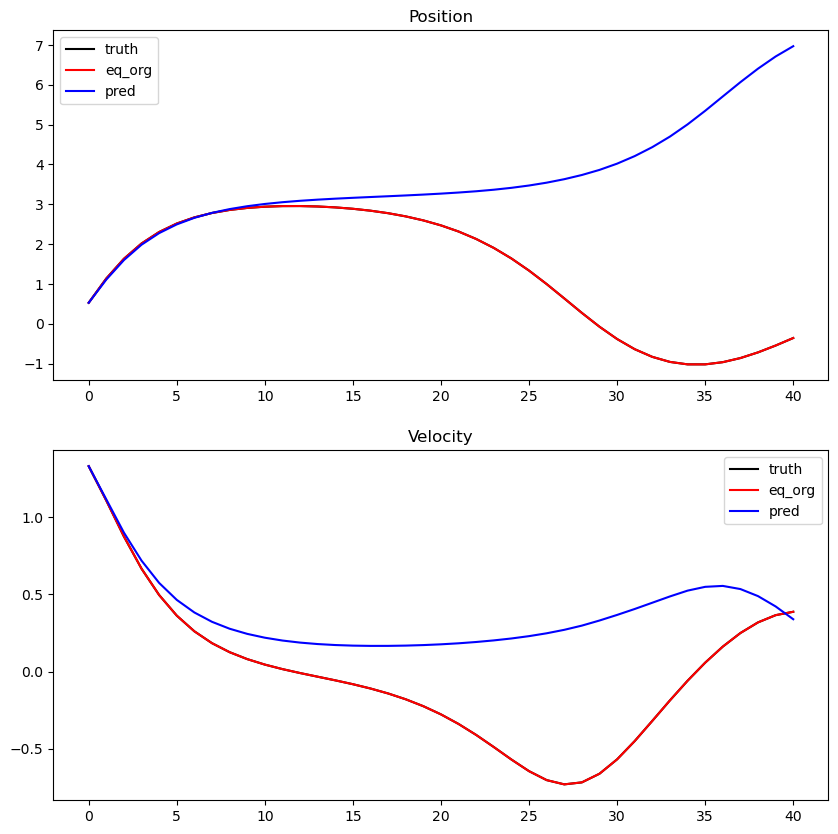

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 41)


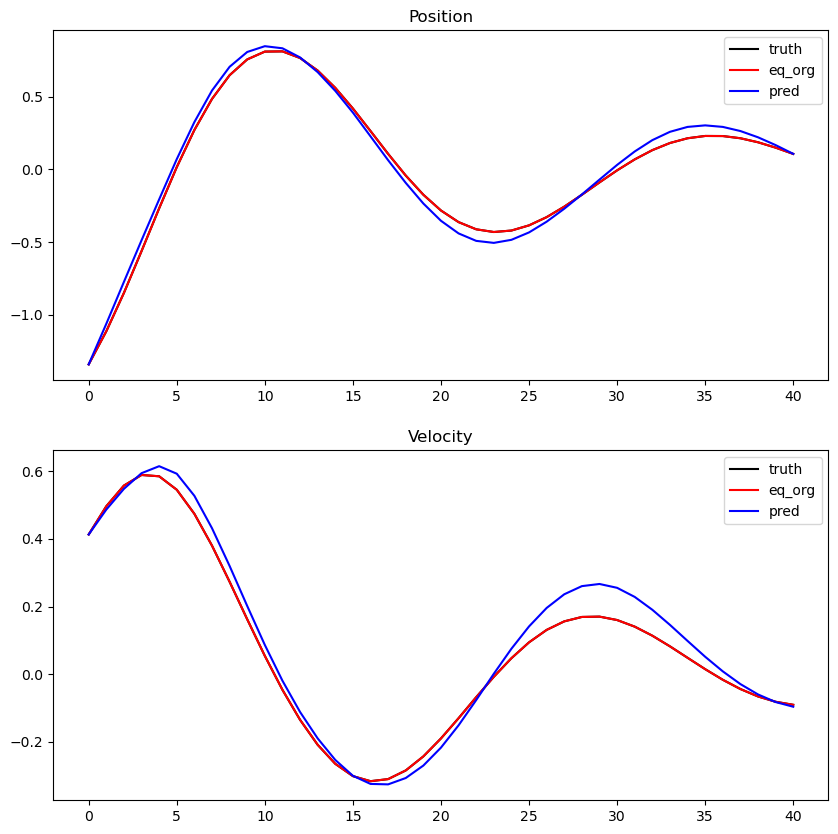

In [11]:
plot_trajectory(24)

## SC Trials 17/02 (`data/sanity_checks2`)

In [268]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

In [269]:
def load_results(results_pth):
    results = pd.read_json(results_pth).T
    exp_name = results_pth.split("/")[-2]
    val_loss = float(results_pth.split("_")[-1][:-6])

    # add initial conditions to dataframe
    results["q0"] = results["states"].apply(lambda x: x[0][0])
    results["p0"] = results["states"].apply(lambda x: x[1][0])
    return results, exp_name, val_loss

In [288]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [289]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


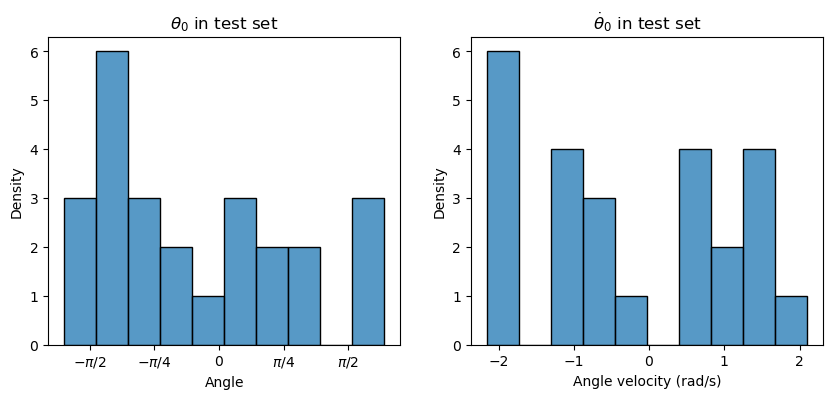

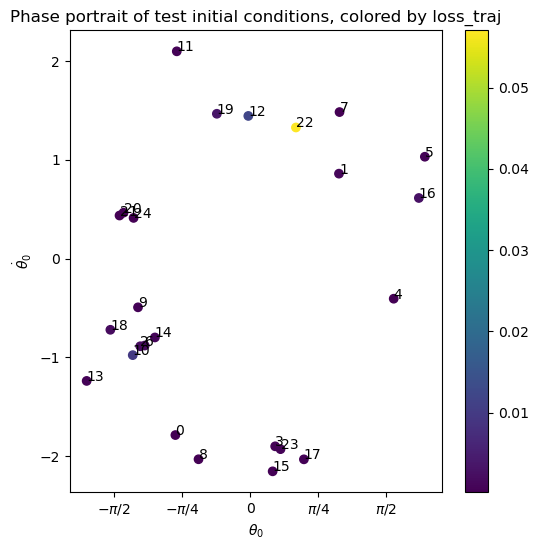

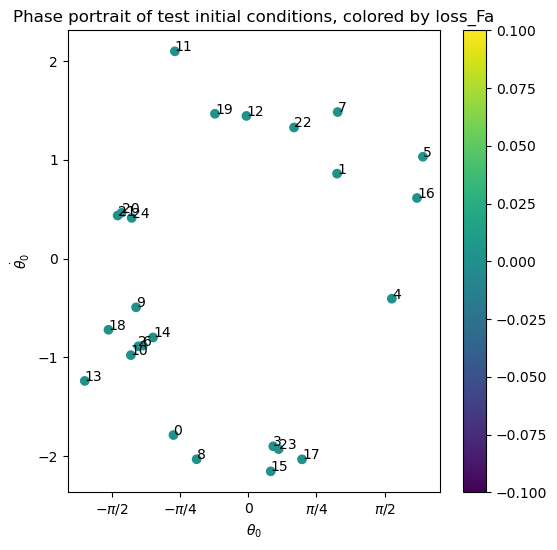

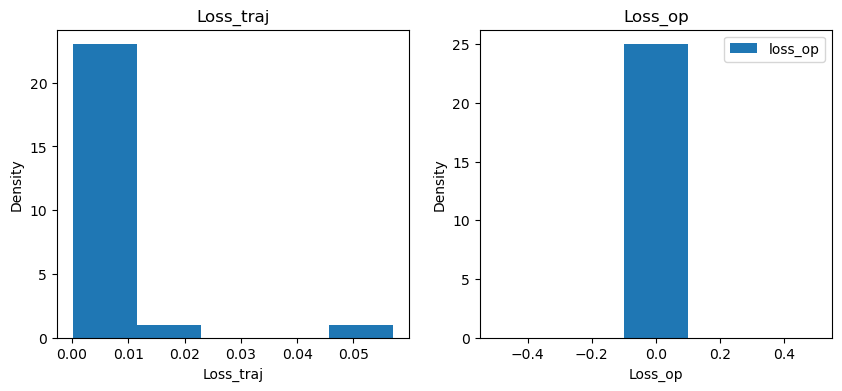

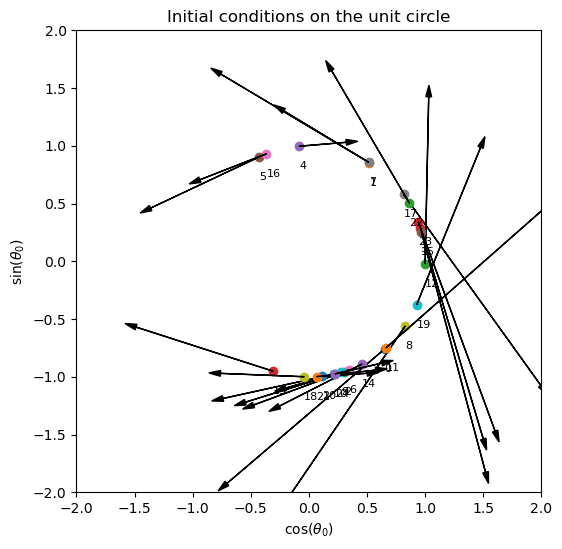

In [290]:
def viz_CI_regimes(res, type="test"):
    # subplot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # choose boxes of the histogram
    sns.histplot(res["q0"], ax=ax[0], bins=10)
    ax[0].set_title(rf"$\theta_0$ in {type} set")
    ax[0].set_xlabel("Angle")
    ax[0].set_ylabel("Density")
    ax[0].set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax[0].set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])

    sns.histplot(res["p0"], ax=ax[1], bins=10)
    ax[1].set_title(fr"$\dot\theta_0$ in {type} set")
    ax[1].set_xlabel("Angle velocity (rad/s)")
    ax[1].set_ylabel("Density")
    plt.show()

    # portrait de phase 
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]))
    if type == "train":
        plt.scatter(res["q0"], res["p0"], label="Initial conditions")
        plt.title(f"Phase portrait of {type} initial conditions")
    else:
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
        plt.colorbar()
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    
    plt.show()

    # portrait de phase colored by loss_Fa
    if type != "train":
        fig, ax = plt.subplots(1,1,figsize=(6, 6))
        # put index of traj above the point
        for i, txt in enumerate(res.index):
            ax.annotate(txt, (res["q0"][i], res["p0"][i]))
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_op"], cmap="viridis")
        plt.xlabel(r"$\theta_0$")
        plt.ylabel(r"$\dot{\theta}_0$")
        ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
        ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
        plt.colorbar()
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_Fa")
        plt.show()

        # histograms of loss_traj and loss_op
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        res["loss_traj"].plot.hist(ax=ax[0], bins=5)
        ax[0].set_title(r"Loss_traj")
        ax[0].set_xlabel("Loss_traj")
        ax[0].set_ylabel("Density")
        res["loss_op"].plot.hist(ax=ax[1], bins=5)
        ax[1].set_title(r"Loss_op")
        ax[1].set_xlabel("Loss_op")
        ax[1].set_ylabel("Density")
        plt.legend()
        plt.show()


    # circular histogram
    # square figure
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    for i, txt in enumerate(res.index):
        # position
        theta = res["q0"][i]
        plt.scatter(np.cos(theta),np.sin(theta))
        ax.annotate(txt, (np.cos(theta),np.sin(theta)-0.2), fontsize=8)
        # add arrow for velocity
        norm = res["p0"][i]
        ax.arrow(np.cos(theta), np.sin(theta), -norm*np.sin(theta), norm*np.cos(theta), head_width=0.05, head_length=0.1, fc='k', ec='k')
    plt.ylim([-2,2])
    plt.xlim([-2,2])
    plt.xlabel(r"cos($\theta_0$)")
    plt.ylabel(r"sin($\theta_0$)")
    plt.title("Initial conditions on the unit circle")


viz_CI_regimes(results)

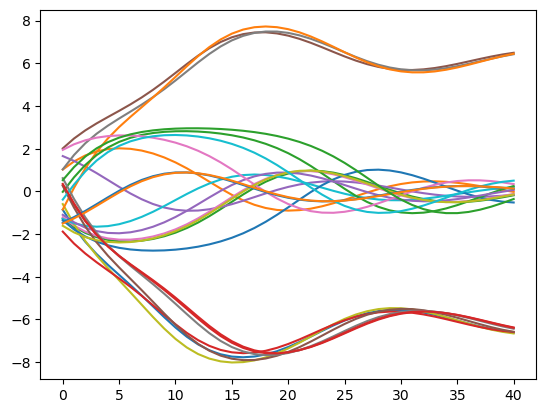

In [291]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[0], label="q")

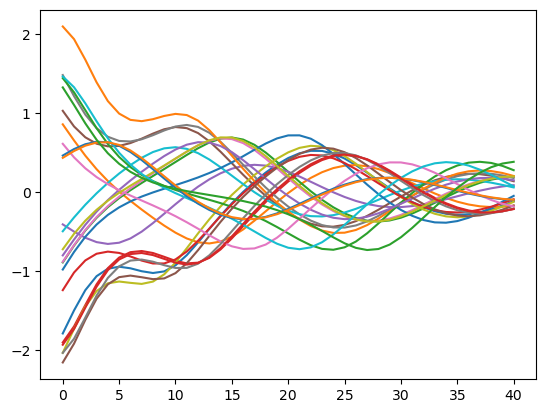

In [292]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[1], label="p")

In [293]:
def plot_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    y0 = np.array(results["states"][index])[:,0]
    # set y max
    ax[0].set_ylim([-8, 8])
    ax[1].set_ylim([-2.1,2.1])

    ax[0].set_title(f"Trajectory {index}: position, q0={round(float(y0[0]),3)}") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="gray")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="darkorange")
    # add regime areas
    # multiples de 2pi
    null_angles = [k*np.pi for k in range(-2, 3, 2)]
    i=0
    for angle in null_angles:
        if i ==0:
            ax[0].axhline(y=angle, color='black', linestyle='--', label="q=0")
        else:
            ax[0].axhline(y=angle, color='black', linestyle='--')
        i+=1
    ax[0].axhline(y=np.pi, color='orangered', linestyle='--', label="turn")
    ax[0].axhline(y=-np.pi, color='orangered', linestyle='--')
    # set ticks with labels
    ax[0].set_yticks(null_angles + [np.pi, -np.pi])
    # write pi in latex style
    ax[0].set_yticklabels(["-2$\pi$", "0",  "2$\pi$", "$\pi$", "-$\pi$"])
    ax[0].set_xlabel("Time steps")
    ax[0].set_ylabel("Angle (rad)")
    ax[0].legend()

    ax[1].set_title(f"Trajectory {index}: velocity, p0={round(float(y0[1]),3)}")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="gray")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="lightseagreen")
    # null velocity line
    ax[1].axhline(y=0, color='black', linestyle='--', label="p=0")
    ax[1].set_xlabel("Time steps")
    ax[1].set_ylabel("Angle velocity (rad/s)")
    ax[1].legend()

    fig.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

## Train data 

In [294]:
# train data viz
from datasets import * 
import os
path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _,_ = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

train.dataset

In [295]:
for i, train_data in enumerate(train):
    print(train_data["states"].shape)

torch.Size([25, 2, 41])


In [296]:
y0 = train_data["states"][:,:,0]
y0 = pd.DataFrame(y0, columns=["q0", "p0"])
y0

,q0,p0
0,-1.334527,0.894015
1,-0.144654,-2.158659
2,0.262720,1.561437
3,1.402906,1.221938
4,1.519548,-1.305323
5,2.101425,-0.089342
6,1.486833,-0.771030
7,1.659655,1.451410
8,1.759936,-0.704725
9,-0.974419,-1.359348


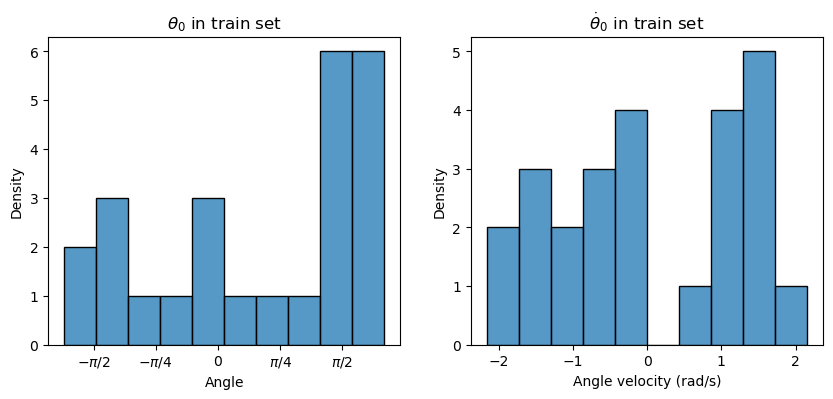

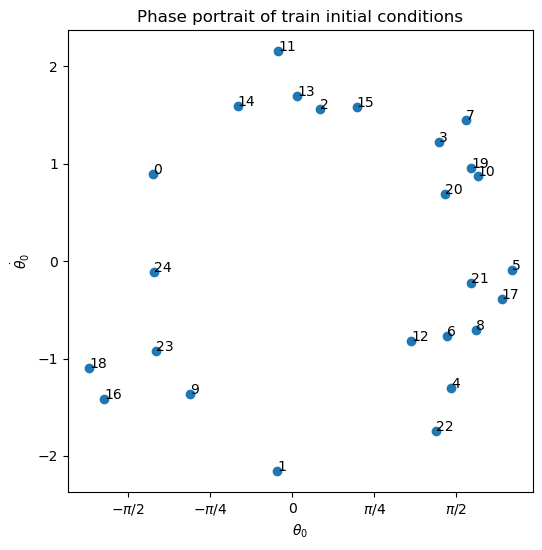

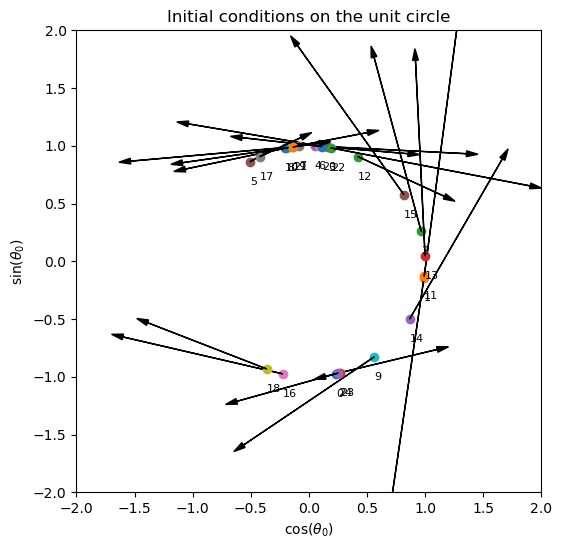

In [297]:
viz_CI_regimes(y0, type="train")

## None aug 16

In [298]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/none_aug_16_1m63z5th/model_6.047e-02..json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('none_aug_16_1m63z5th', 0.06047)

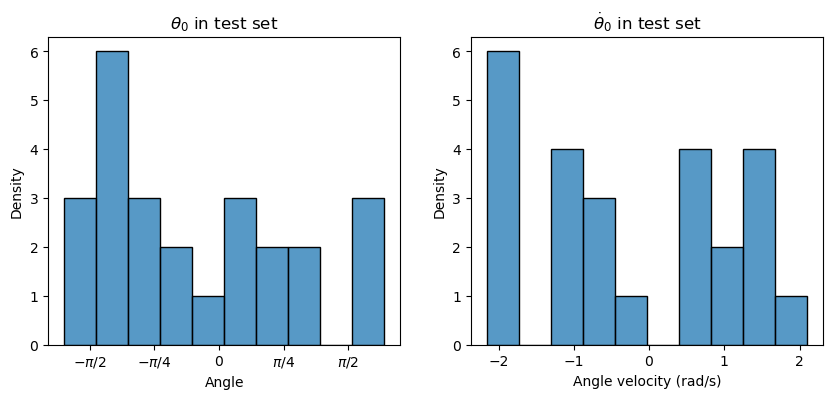

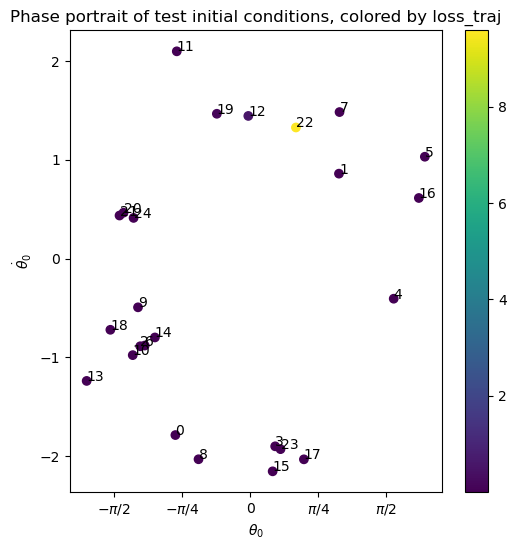

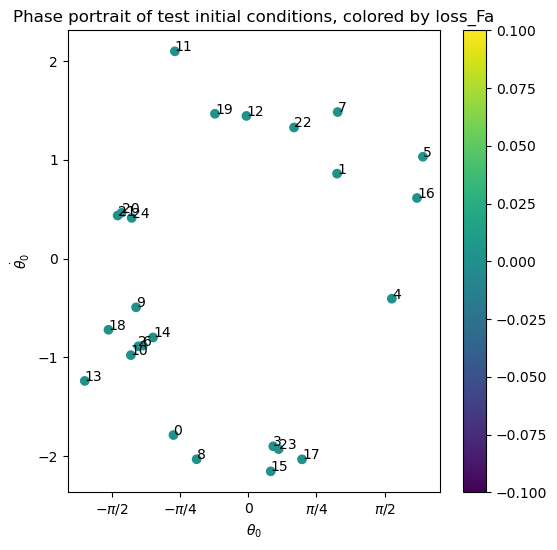

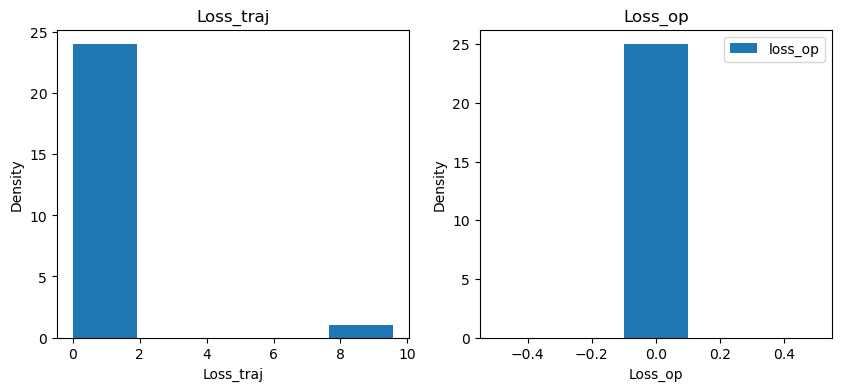

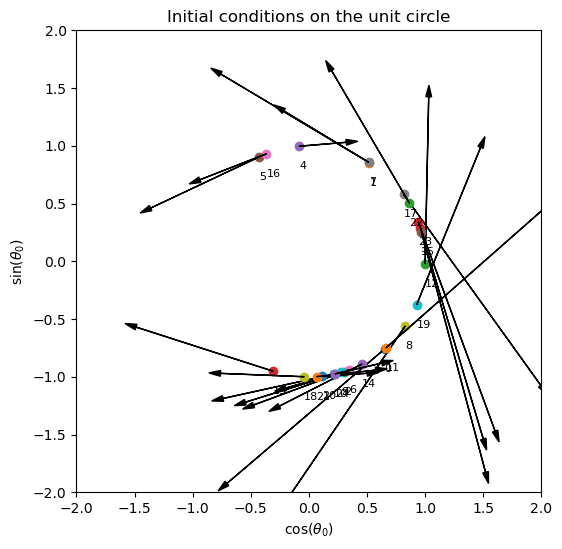

In [299]:
viz_CI_regimes(results)

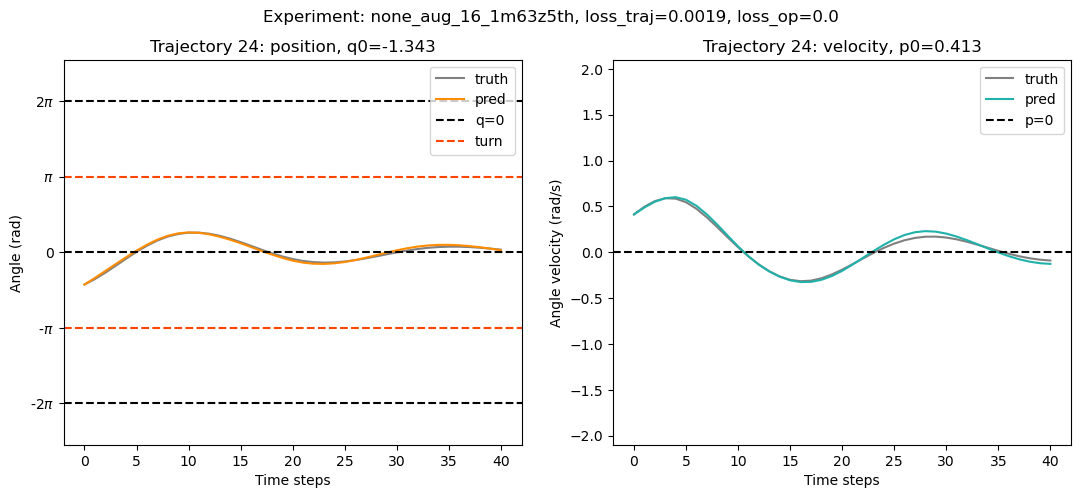

In [300]:
plot_trajectory(results, exp_name, 24)

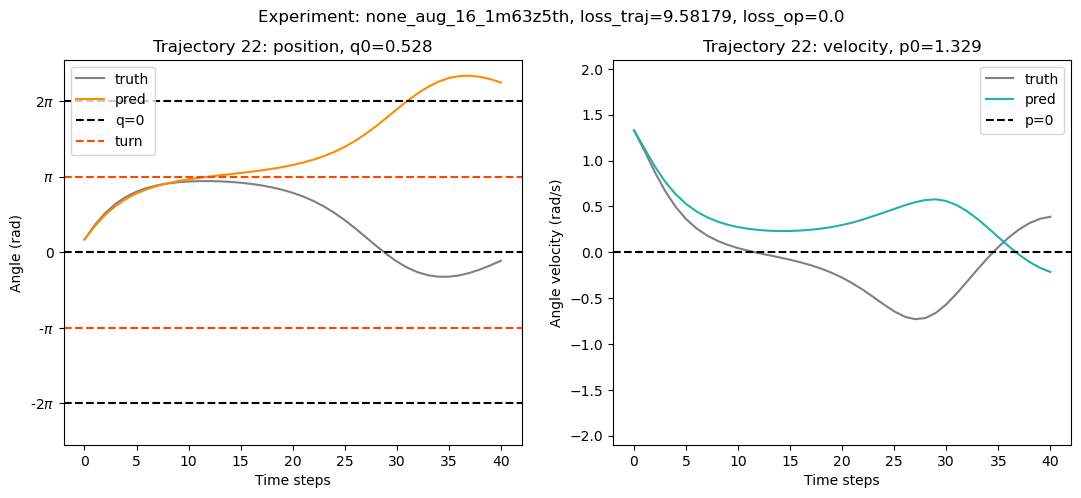

In [301]:
plot_trajectory(results, exp_name, 22)

## complete physics 14

Final omega: 0.28003543615341187, Final alpha: 0.196983486413955

In [302]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [303]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


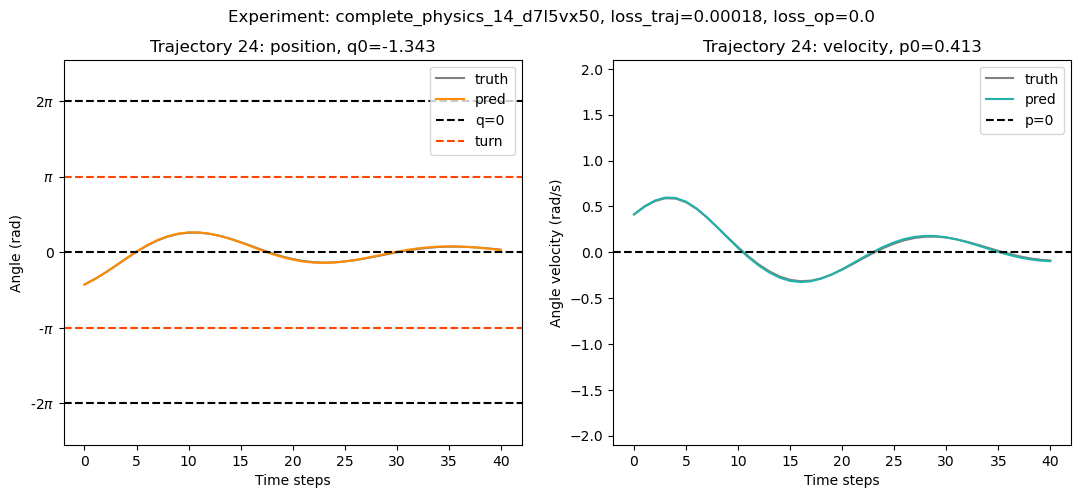

In [304]:
plot_trajectory(results, exp_name, 24)

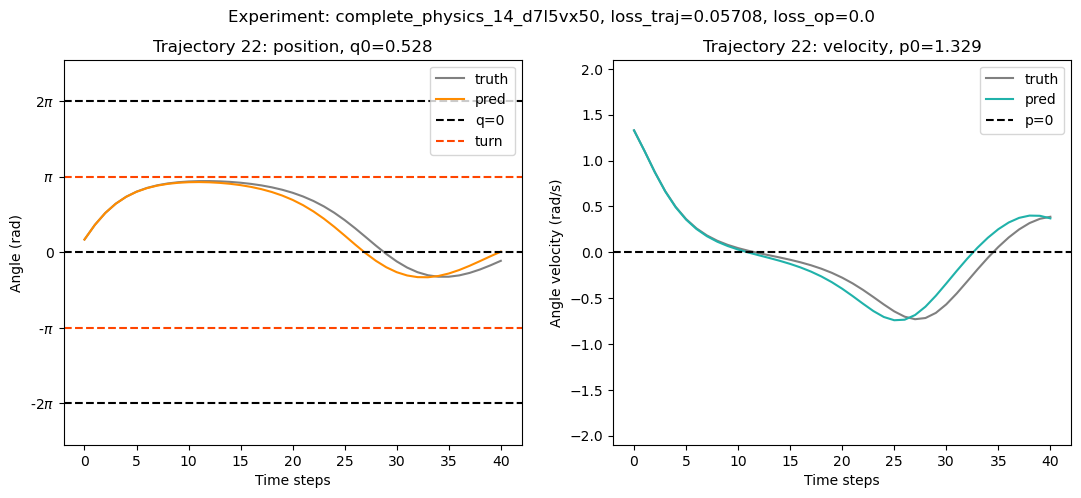

In [305]:
plot_trajectory(results, exp_name, 22)

### incomplete aug 17: wrong loss 
Final omega: 0.2073115110397339, Final alpha: 0.0

In [306]:
path = '/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_17_m9bz4n8c/model_2.790e+00.json'
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_17_m9bz4n8c', 2.79)

In [307]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6506702899932861, -2...",0.143378,0.001966,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.429108142852783, 1.76517...",1.285091,0.000516,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.638038635253906, -1.9...",0.632978,0.001288,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.626850128173828, -1....",0.069507,0.001914,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.4389311075210571, 1.179...",0.347999,0.000442,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.484290599822998, 2.8936...",0.034732,0.000359,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.58401083946228, -1.87...",0.609975,0.001255,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.739323139190673, 2.3589...",0.145952,0.000423,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.510691046714782, -2....",0.1201,0.002042,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494427680969238, -1.6...",0.399011,0.000848,-1.292473,-0.493132


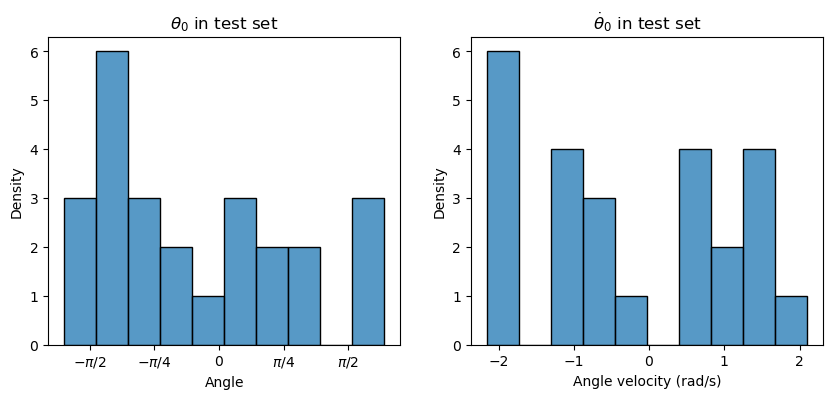

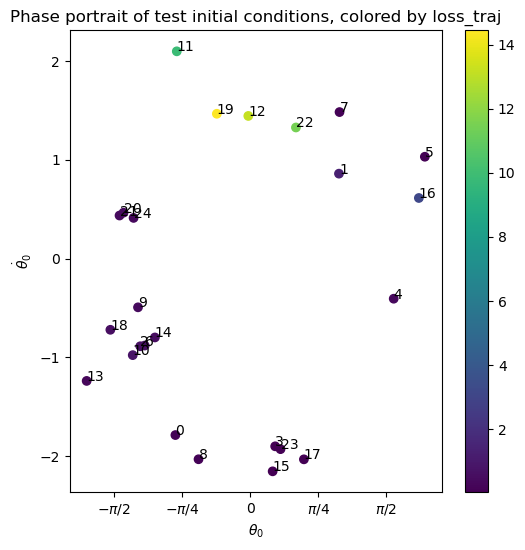

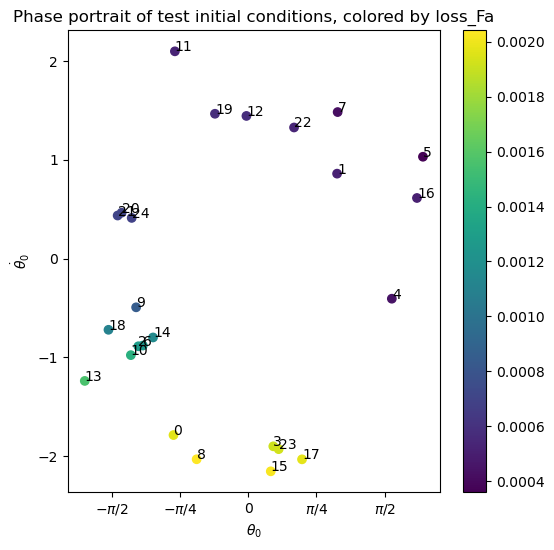

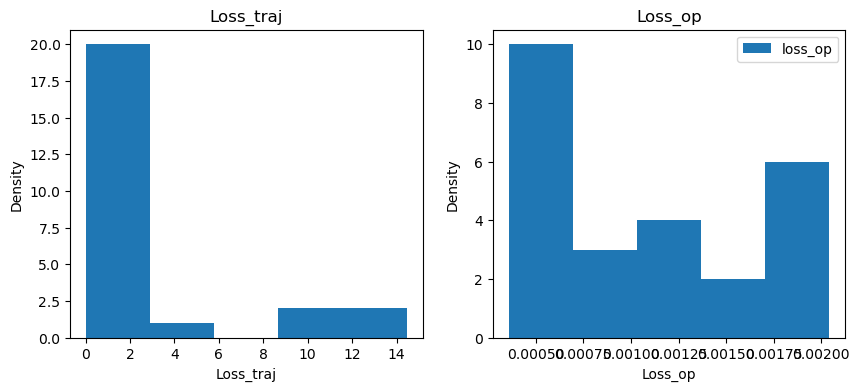

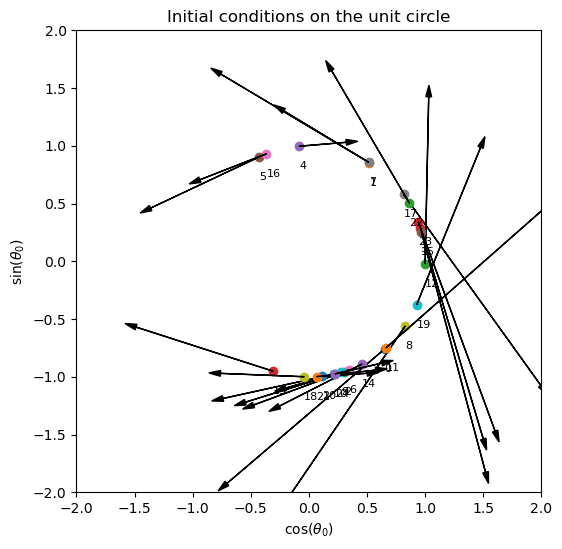

In [308]:
viz_CI_regimes(results)

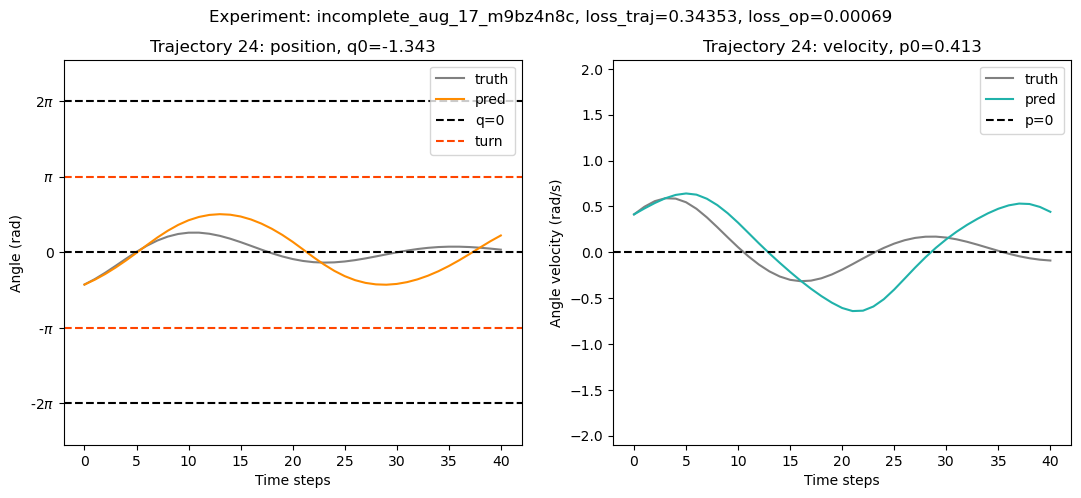

In [233]:
plot_trajectory(results, exp_name, 24)

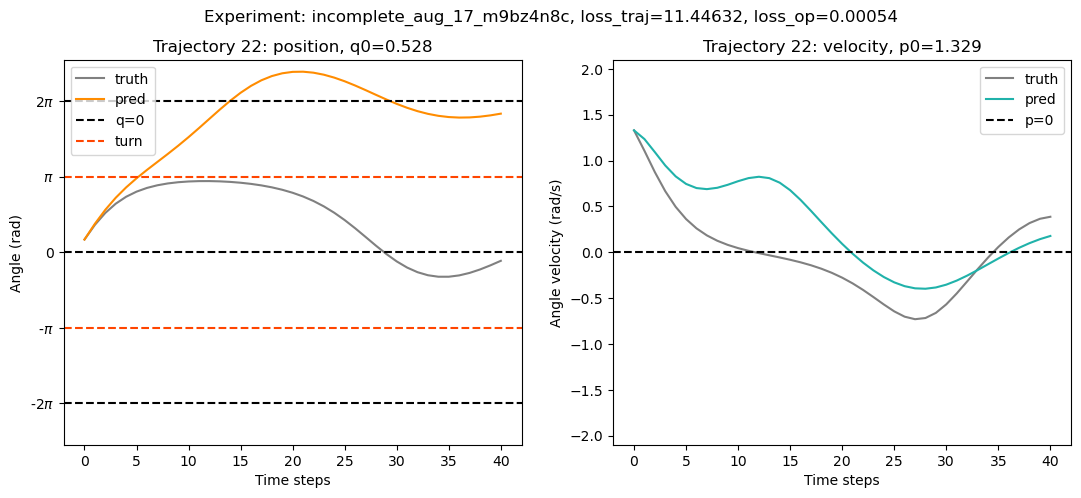

In [234]:
plot_trajectory(results, exp_name, 22)

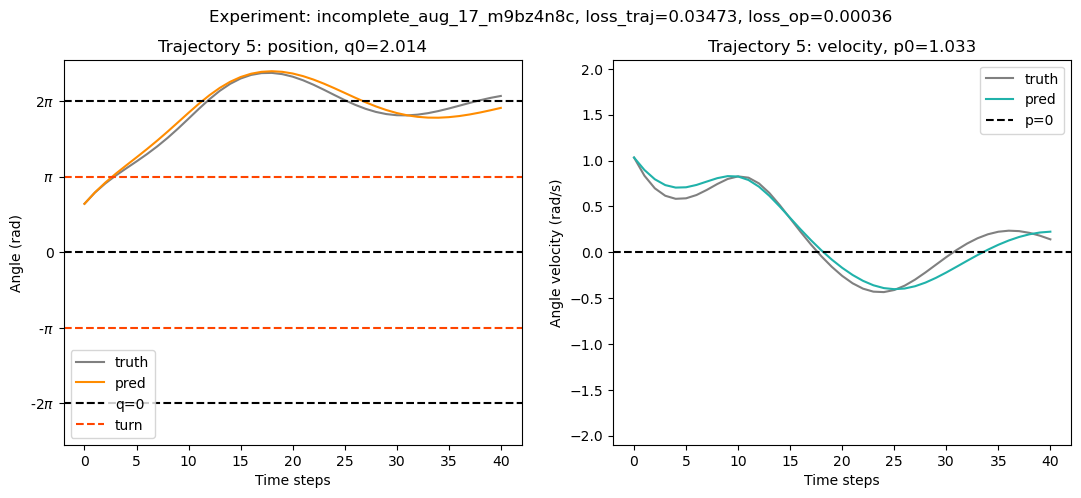

In [235]:
plot_trajectory(results, exp_name, 5)

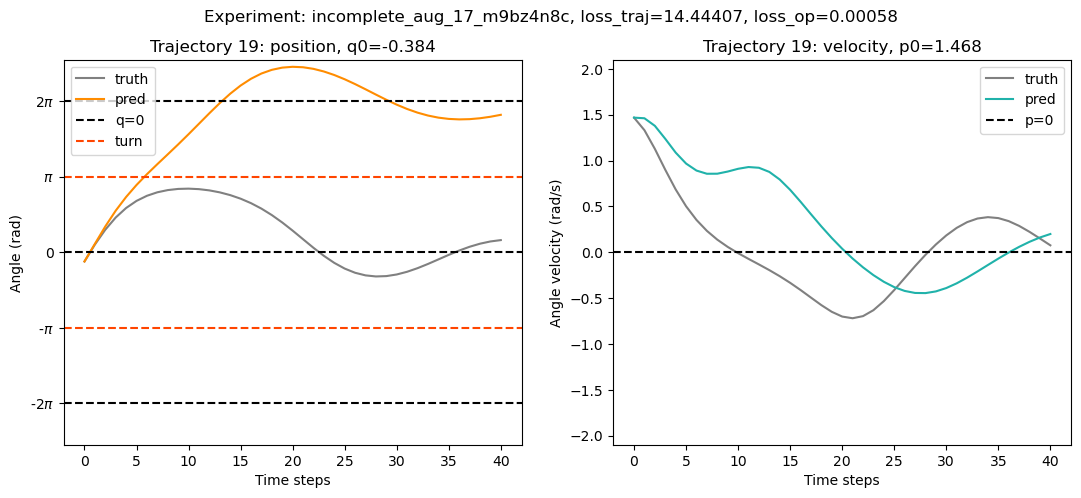

In [236]:
plot_trajectory(results, exp_name, 19)

## incomplete aug 19
Final omega: 0.22525587677955627, Final alpha: 0.0

In [309]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_19_korcnphf/model_2.400e+00.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_19_korcnphf', 2.4)

In [310]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.277207612991333, -1....",10.760328,0.611657,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.263813138008117, 1.43468...",0.818055,3.079111,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.395644307136535, -1.4...",1.165683,2.029806,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.26815548539161604, -...",9.761674,0.691293,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.33664870262146, 1.00300...",0.94818,6.029916,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.424787759780884, 2.7662...",0.038825,0.000919,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.352573156356811, -1.3...",1.162419,2.388407,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.646154522895813, 2.1580...",0.031189,0.001775,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.120106697082519, -1....",11.397531,0.622855,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.359453797340393, -1.4...",1.19821,6.289103,-1.292473,-0.493132


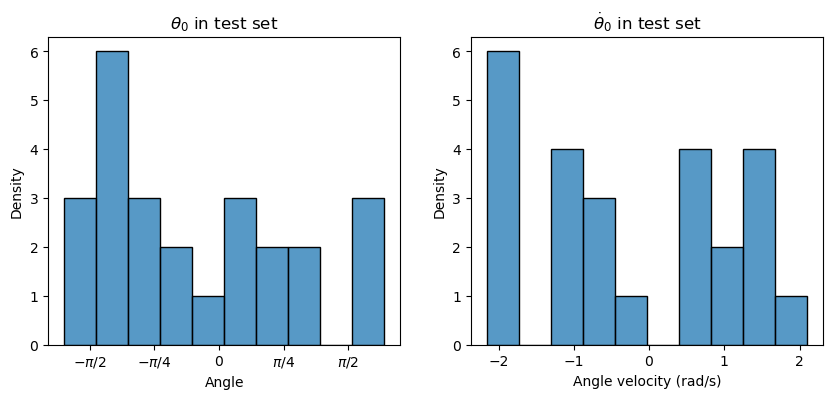

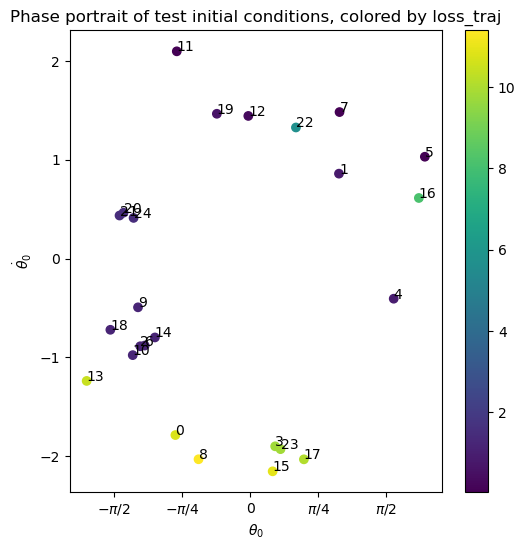

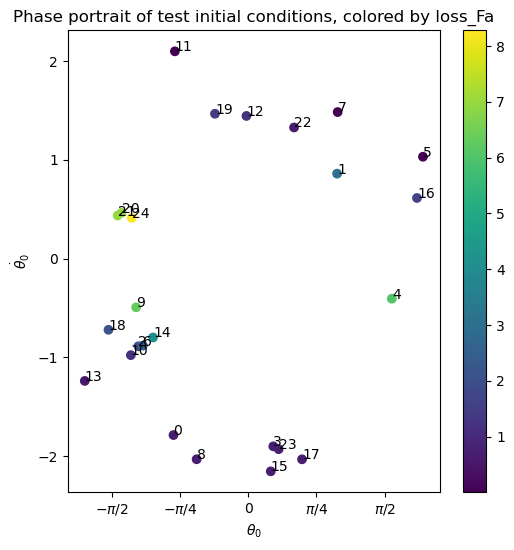

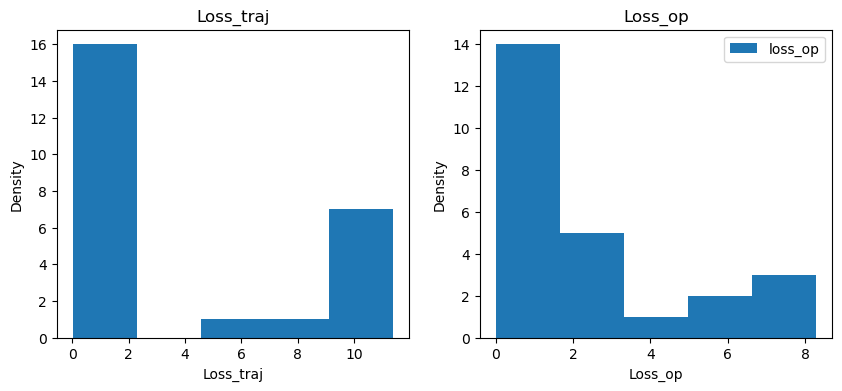

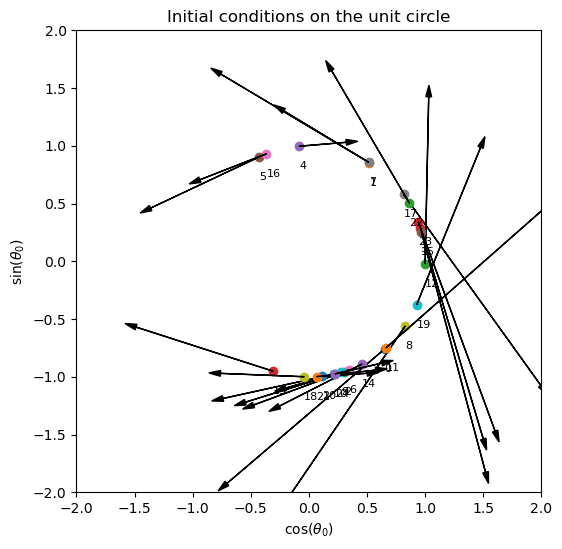

In [311]:
viz_CI_regimes(results)

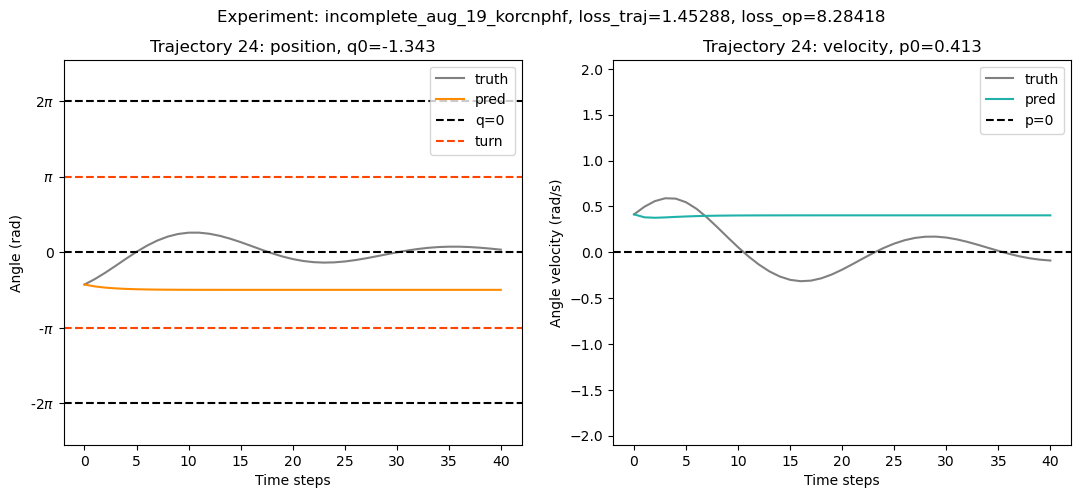

In [312]:
plot_trajectory(results, exp_name, 24)

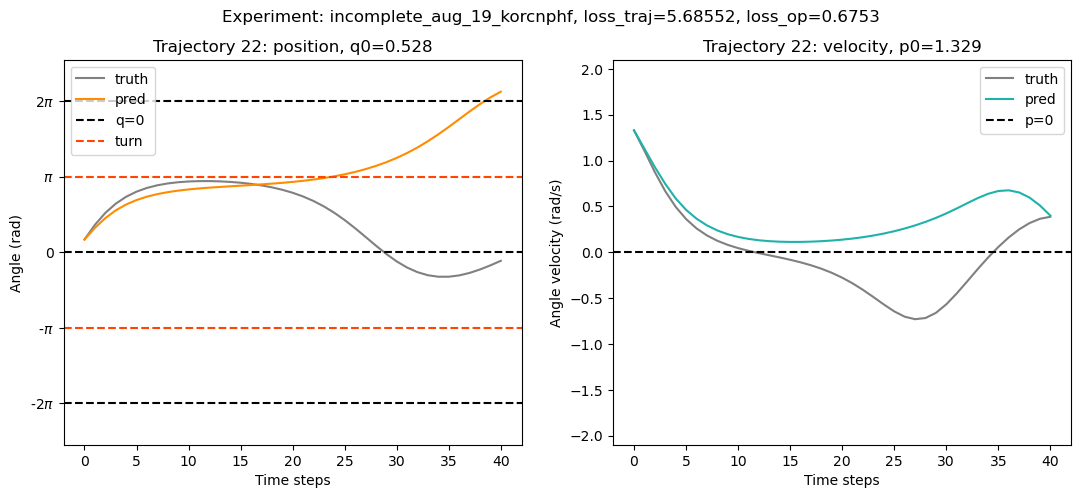

In [313]:
plot_trajectory(results, exp_name, 22)  

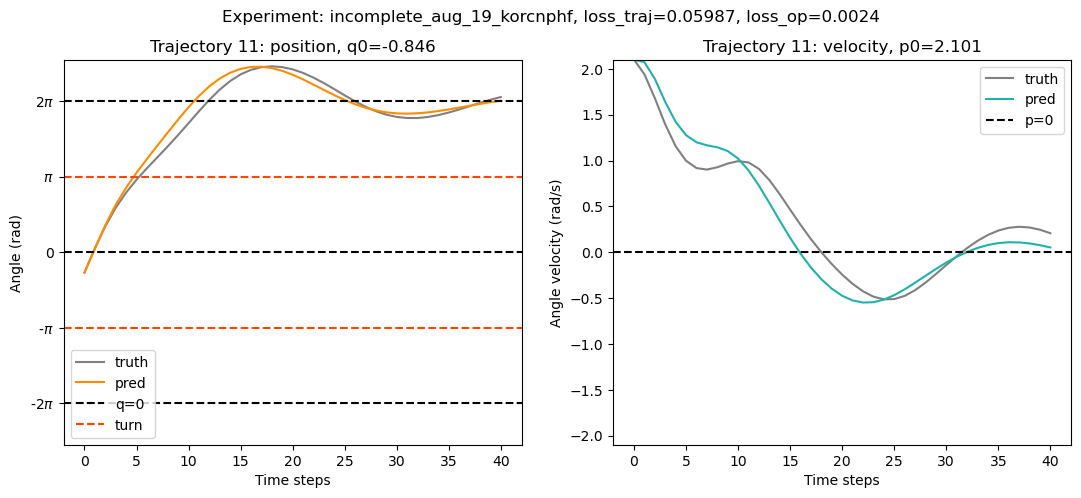

In [314]:
plot_trajectory(results, exp_name, 11)

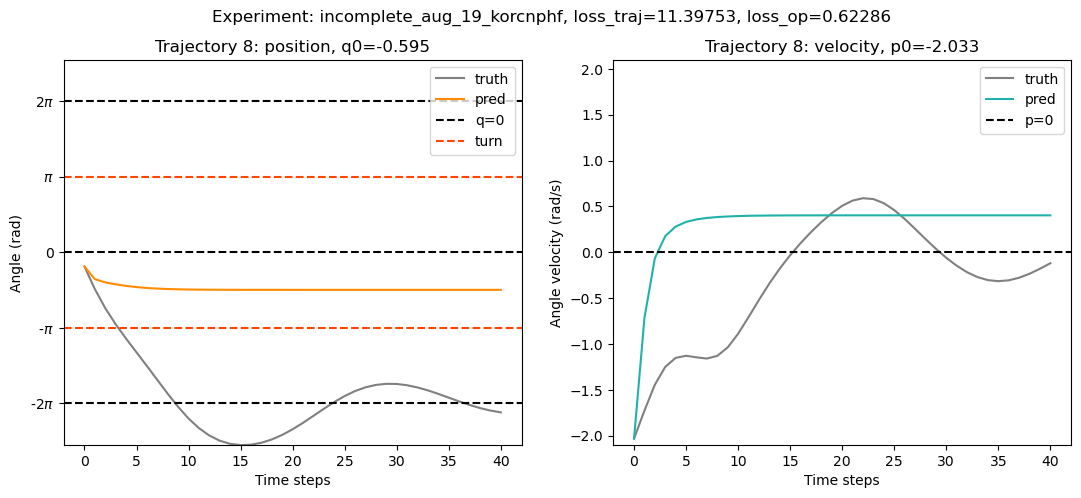

In [315]:
plot_trajectory(results, exp_name, 8)